In [10]:
import pandas as pd
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
from langchain.agents import AgentType
from langchain.chat_models import AzureChatOpenAI
from langchain.prompts import PromptTemplate


In [27]:
final_df = pd.read_csv(r"C:\Bizmetric\vedanta\ebitda_walk.csv")
ytd_df = pd.read_csv(r"C:\Bizmetric\vedanta\data_ytd.csv")

In [28]:
final_df

,Period,EBITDA_From_Quarter,Sales,LME,Strategic Hedging,Premium,Realization,Total Cost,Alumina,Power,Other Hot Metal,Conversion & Other,EBITDA_Margin,EBITDA_Impact,EBITDA_To_Quarter
0,EW_Q1FY24_Q1FY24,221,0,0,0,0,0,0,0,0,0,0,0,0,221
1,EW_Q1FY24_Q2FY24,221,9,-59,-2,12,-49,55,43,10,14,-11,7,16,238
2,EW_Q1FY24_Q3FY24,221,13,-38,-5,-1,-44,149,37,25,49,38,106,124,346
3,EW_Q1FY24_Q4FY24,221,15,-33,-5,-8,-46,163,48,14,63,38,117,140,361
4,EW_Q2FY24_Q1FY24,238,-10,61,2,-12,51,-58,-45,-10,-14,11,-7,-16,221
5,EW_Q2FY24_Q2FY24,238,0,0,0,0,0,0,0,0,0,0,0,0,238
6,EW_Q2FY24_Q3FY24,238,3,21,-3,-13,5,98,-6,17,37,51,103,108,346
7,EW_Q2FY24_Q4FY24,238,6,27,-3,-21,3,112,5,5,51,51,115,123,361
8,EW_Q3FY24_Q1FY24,346,-18,41,5,1,46,-158,-39,-27,-51,-40,-112,-124,221
9,EW_Q3FY24_Q2FY24,346,-5,-22,3,13,-5,-99,6,-17,-37,-51,-105,-108,238


In [26]:
llm = AzureChatOpenAI(
            api_key= "d06dfb8d9f2e4d9696bfb614c8da2a69" ,
            azure_endpoint= "https://cog-ccgt327nxe3tc.openai.azure.com",
            openai_api_version="2024-02-01",  # Ensure this matches your Azure API version
            model="gpt-4o",
            deployment_name= "biz-gpt-4o",
            temperature=0
)

In [29]:

# Define the function
def analyze_data(query, llm, final_df, ytd_df):
    # Initialize LLM
    

    # Custom prompt template
    custom_prompt = PromptTemplate.from_template("""
    You are a data analyst with access to the following dataframes: final_df and ytd_df.
    Use them to answer user questions. Be accurate and explain your reasoning if needed.

    IMPORTANT:
    - The row EW_Q2FY24_Q3FY24 means **starting from Q2FY24 and walking to Q3FY24**.
    - The reverse journey, from Q3FY24 to Q2FY24, is **not simply the negative of the forward journey**.
    - Do **NOT reverse** the direction by subtracting values from an earlier row — instead, check if such a reverse path row like `EW_Q3FY24_Q2FY24` exists in the dataframe.

    Analysis Expectations:
    - Only use the exact row like `EW_QxFY24_QyFY24` to analyze the walk **from Qx to Qy**.
    - Explain component-wise impact using columns like: Sales, LME, Strategic Hedging, Premium, Realization, Total Cost, Alumina, Power, Other Hot Metal, Conversion & Other.
    - Give summary of total EBITDA_Impact and major contributors.

    Positive values = positive impact on EBITDA

    Negative values = negative impact on EBITDA
    """)

    # Create the agent
    agent = create_pandas_dataframe_agent(
        llm=llm,
        df=[final_df, ytd_df],
        agent_type=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
        prompt=custom_prompt,
        verbose=False,
        handle_parsing_errors=True,
        allow_dangerous_code=True
    )

    # Invoke the agent with the input query
    response = agent.invoke({"input": query})
    
    return response["output"]

In [30]:
query = "Give me the analysis of EBITDA walk from Q2FY24 to Q3FY24."

In [6]:
query = "Give me the ytd Q2FY24"


In [31]:
result = analyze_data(query, llm, final_df, ytd_df)

# Print the result
print(result)

c:\Bizmetric\vedanta\.venv\Lib\site-packages\langchain_experimental\agents\agent_toolkits\pandas\base.py:283: UserWarning: Received additional kwargs {'prompt': PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='\n    You are a data analyst with access to the following dataframes: final_df and ytd_df.\n    Use them to answer user questions. Be accurate and explain your reasoning if needed.\n\n    IMPORTANT:\n    - The row EW_Q2FY24_Q3FY24 means **starting from Q2FY24 and walking to Q3FY24**.\n    - The reverse journey, from Q3FY24 to Q2FY24, is **not simply the negative of the forward journey**.\n    - Do **NOT reverse** the direction by subtracting values from an earlier row — instead, check if such a reverse path row like `EW_Q3FY24_Q2FY24` exists in the dataframe.\n\n    Analysis Expectations:\n    - Only use the exact row like `EW_QxFY24_QyFY24` to analyze the walk **from Qx to Qy**.\n    - Explain component-wise impact using columns like: Sales, LME

The EBITDA walk from Q2FY24 to Q3FY24 shows a total impact of 108 units, resulting in an increase from 238 to 346. Key changes include increases in LME (21), Total Cost (98), and Conversion & Other (51), with decreases in Premium (-13) and Strategic Hedging (-3).


In [41]:
# Step 1: Import necessary libraries
import os
import pandas as pd
from pandasai import Agent
from openai import OpenAI


In [34]:
def run_ytd_analysis_plot(ytd_df, query, llm):
    
    agent = Agent(ytd_df, config={
        "llm": llm,
        "cache": False })

    result = agent.chat(query)

    

    return result

In [42]:
def fig_to_base64(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png")
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

def run_ytd_analysis_plot(ytd_df, query, llm):
    
    agent = Agent(ytd_df, config={
        "llm": llm,
        "cache": False })

    result = agent.chat(query)

    

    # If `result` is a matplotlib figure
    if isinstance(result, plt.Figure):
        return {"type": "image", "data": fig_to_base64(result)}
    else:
        return {"type": "text", "data": result}

In [43]:
query = "plot barplot of ytd of Q2."

{'type': 'text', 'data': 'c:/Bizmetric/vedanta/exports/charts/temp_chart.png'}

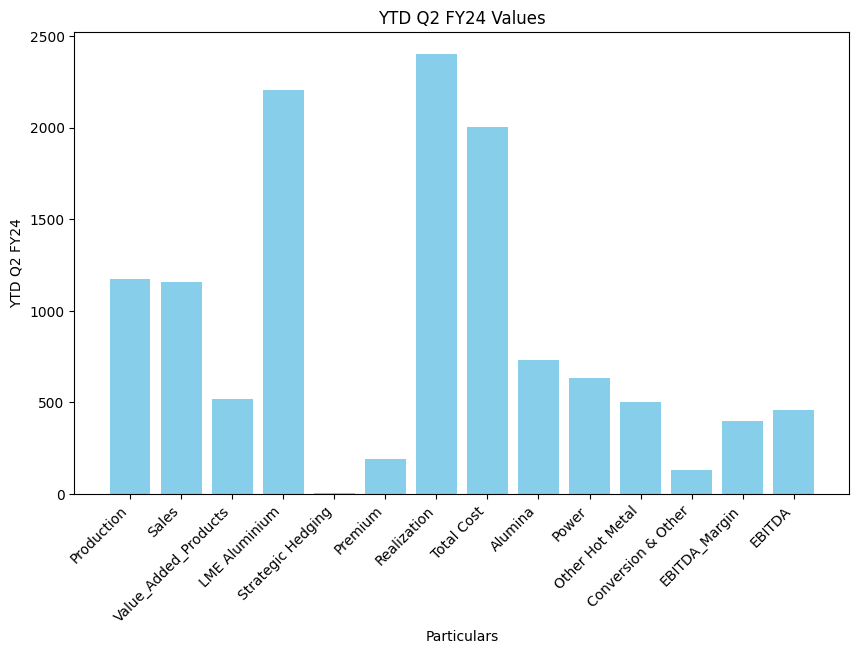

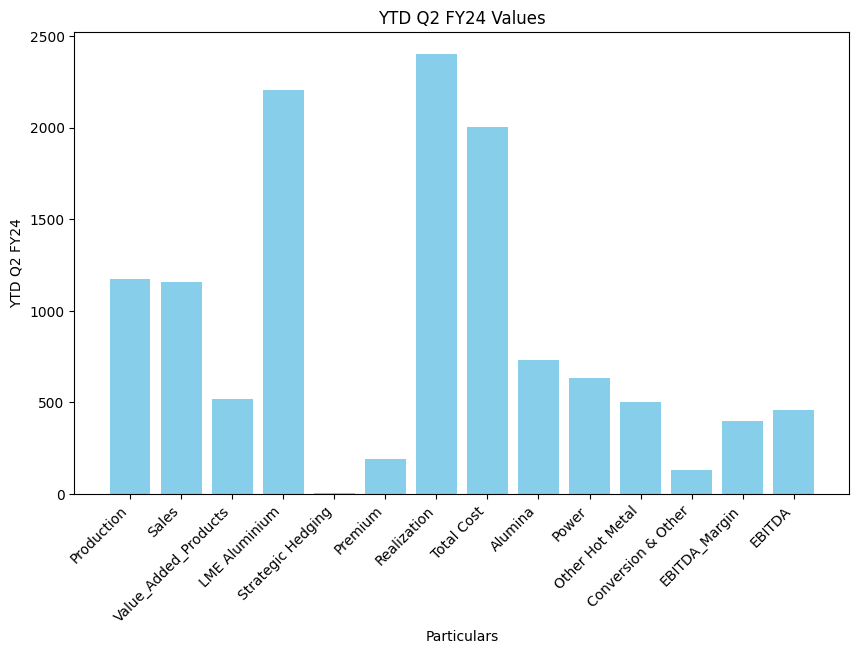

In [44]:
run_ytd_analysis_plot(ytd_df, query, llm)

In [46]:
import os
import pandas as pd
from fastapi import FastAPI, Query
from pydantic import BaseModel
from fastapi.responses import FileResponse
from langchain_core.tools import tool
# from pandasai import Agent
# from pandasai.llm import AzureOpenAI
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
from langchain.agents import AgentType
from langchain.prompts import PromptTemplate
from langgraph.prebuilt import create_react_agent
from langchain_openai import AzureChatOpenAI
from src.plot_ebitda_walk import run_ebitda_walk_analysis_plot
from src.plot_ytd import run_ytd_analysis_plot
from src.data_analysis import analyze_data

In [47]:
def create_tools():
    @tool
    def ebitda_walk_tool(query: str) -> dict:
        """
        Use this tool to generate a detailed EBITDA Walk chart **ONLY** when the question is 
        about how EBITDA changes **from one quarter to another**, like "Q1 to Q3", "Q2 to Q1", etc.
        .
        - Analysis Expectations:
        - Only use the exact row like `EW_QxFY24_QyFY24` to analyze the walk **from Qx to Qy**.
        - Give summary of total EBITDA_Impact and major contributors.
        """
        # return run_ebitda_walk_analysis_plot(final_df, query, llm)
        print ("function :ebitda_walk_tool")
        image_path = run_ebitda_walk_analysis_plot(final_df, query, llm)
        return {"type": "image", "data": image_path}

    @tool
    def ytd_plot_tool(query: str) -> dict:
        """ 
        Use this tool to generate Year-To-Date (YTD) visualizations or when the user asks for a 
        **YTD trend or YTD bar chart** for a quarter.
        - for plots related to 
            Production
            Sales
            Value Added Products
            LME Aluminium
            Strategic Hedging
            Premium
            Realization
            Total Cost
            Alumina
            Power
            Other Hot Metal
            Conversion & Other
            EBITDA Margin
            EBITDA

        Examples:
        - "Plot YTD sales across Q1 to Q3"
        - "Show YTD trend of EBITDA"
        - " Draw bar plot for sales"
        """
        print ("function :ytd_plot_tool")
        image_path = run_ytd_analysis_plot(ytd_df, query, llm)
        return {"type": "image", "data": image_path}
    @tool
    def general_text_analysis(query: str) -> dict:
        """
        Use this tool for general text-based financial insights, including:
        - Quarter-level values (like "Give sales in Q2") for 
        - Stricly Quarter-level KPIs (e.g., "Sales in Q2") use ytd_df as just want give quarter values
        - Retrieval of Data/Number Search (Display results of specific queries ex. Alumina Cost in Q3) use ytd_df
        - Component-wise EBITDA breakdowns
        - Simple summaries or comparisons
        - YTD values in text (not chart form)
        This tool is best when no plot is requested, and the question can be answered in plain text.
        """
        return {"type": "text", "data": analyze_data(query, llm, final_df, ytd_df)}
    
    return [ebitda_walk_tool, ytd_plot_tool, general_text_analysis]
    
    



def create_multi_tool_agent():
    tools = create_tools()
    llm = llm = AzureChatOpenAI(
            api_key= "d06dfb8d9f2e4d9696bfb614c8da2a69" ,
            azure_endpoint= "https://cog-ccgt327nxe3tc.openai.azure.com",
            openai_api_version="2024-02-01",  # Ensure this matches your Azure API version
            model="gpt-4o",
            deployment_name= "biz-gpt-4o",
            temperature=0
)
    agent = create_react_agent(
        llm,
        tools,
        prompt="""
        You are a financial data assistant with access to three tools:

        ---

        🧰 1. **ebitda_walk_tool**
        - Use this tool to generate visual **EBITDA Walk charts**.
        - ONLY use it when the query clearly asks for **EBITDA change from one quarter to another**, like **"from Q1 to Q3"**.
        - .

        ---

        📈 2. **ytd_plot_tool**
        - Use this to generate **YTD visual plots** across quarters or months.
        - Good for queries like “YTD trend of EBITDA” or “plot YTD from Q1 to Q3”.

        ---

        📊 3. **general_text_analysis**
        - Use this tool for:
            - Stricly Quarter-level KPIs (e.g., "Sales in Q2") use ytd_df as just want give quarter values
            - Retrieval of Data/Number Search (Display results of specific queries ex. Alumina Cost in Q3) use ytd_df
            - Component-wise breakdowns (e.g., "EBITDA impact in Q1")
            - YTD values when no chart is requested
            - analysis on editda walk 
            - use this for analysis related query
            

        ---

        🔁 General Instructions:
        - If a visual is requested, prefer the appropriate plot tool.

        - Never hallucinate charts if they can't be created.

        """,
    )

    return agent


# Initialize global agent
agent_executor = create_multi_tool_agent()

In [49]:
response = agent_executor.invoke("plot barplot of ytd of Q2.")
        message_content = response['messages'][-1].content

        # Wrap it in expected format
        return {"response": {"type": "text", "data": message_content}}
    except Exception as e:
        return {"response": {"type": "error", "data": str(e)}}

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 6)

In [32]:
def run_ebitda_walk_analysis_plot(final_df, query, llm):
    
    agent = Agent(ytd_df, config={
        "llm": llm,
        "cache": False })

    result = agent.chat(query)

    

    return result

In [33]:
query = " plot editda walk from q3 to q1"

'c:/Bizmetric/vedanta/exports/charts/temp_chart.png'

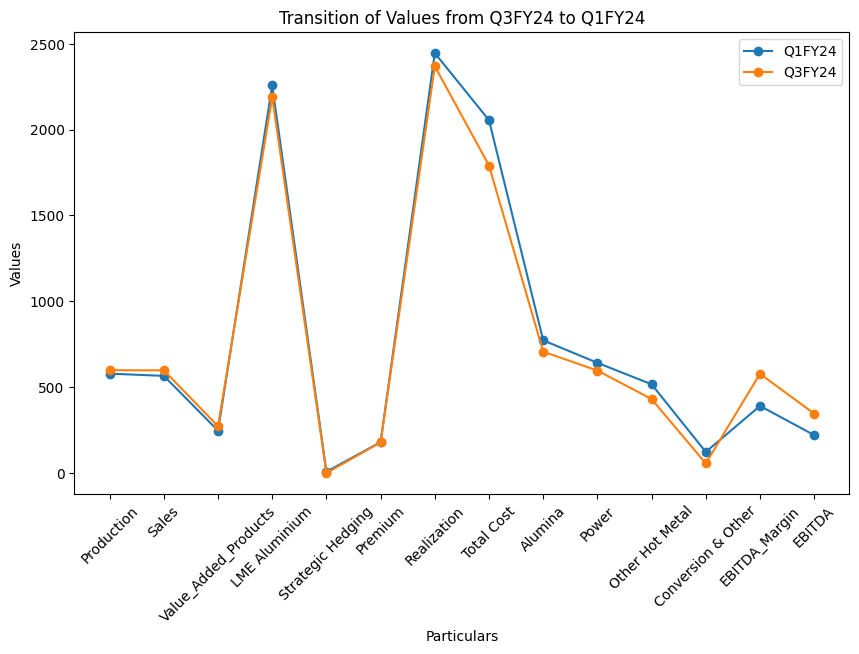

In [10]:
run_ebitda_walk_analysis_plot(final_df, query, llm)

In [17]:
query = " Plot a waterfall chart for EBITDA Walk from Q1FY24 to Q3FY24 "

'c:/Bizmetric/vedanta/exports/charts/temp_chart.png'

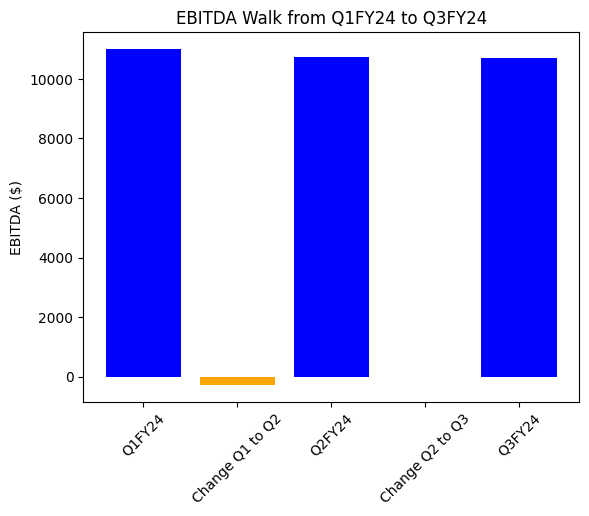

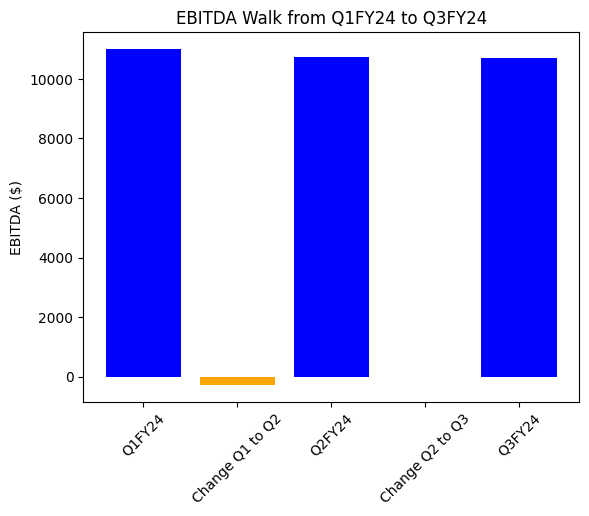

In [18]:
run_ebitda_walk_analysis_plot(final_df, query, llm)

In [23]:
system_prompt = """
You are an expert financial analyst who specializes in visualizing EBITDA Walk analysis.
When the user provides a query, you must generate a waterfall chart:
- Generate a waterfall chart for the EBITDA Walk from QxFY24 to QyFY24 then use row EW_QxFY24_QyFY24 from the dataframe for the values.
- Dark Blue for starting and ending EBITDA bars
- Green for increases, Red for decreases
- Title: "EBITDA Walk (Mn$)"
- Label all bars with category names and value amounts above each bar.
-The components contributing to the movement are:
    EBITDA_From_Quarter	Sales	LME	Strategic Hedging	Premium	Realization	Total Cost	Alumina	Power	Other Hot Metal	Conversion & Other	EBITDA_Margin	EBITDA_Impact	EBITDA_To_Quarter
Be very accurate and clean in the chart presentation.
"""

In [37]:
def run_ebitda_walk_analysis_plot(final_df, query, llm):
    system_prompt = """
        You are an expert financial analyst who specializes in visualizing EBITDA Walk analysis.
        When the user provides a query, you must generate a waterfall chart:
        - Generate a waterfall chart for the EBITDA Walk from QxFY24 to QyFY24 then use row EW_QxFY24_QyFY24 from the dataframe for the values.
        - Dark Blue for starting and ending EBITDA bars
        - Green for increases, Red for decreases
        - Title: "EBITDA Walk (Mn$)"
        - Label all bars with category names and value amounts above each bar.
        -The components contributing to the movement are:
            EBITDA_From_Quarter	Sales	LME	Strategic Hedging	Premium	Realization	Total Cost	Alumina	Power	Other Hot Metal	Conversion & Other	EBITDA_To_Quarter
        Be very accurate and clean in the chart presentation.
        """
    
    agent = Agent(
        final_df,
        config={
            "llm": llm,
            "cache": False,
            "system_prompt": system_prompt  # pass system prompt here
        }
    )

    result = agent.chat(query)
    return result

In [38]:
def run_ebitda_walk_analysis_plot(final_df, query, llm):
    system_prompt = """
        You are an expert financial analyst who specializes in visualizing EBITDA Walk analysis.
        When the user provides a query, you must generate a waterfall chart:
        - Generate a waterfall chart for the EBITDA Walk from QxFY24 to QyFY24 then use row EW_QxFY24_QyFY24 from the dataframe for the values.
        - Dark Blue for starting and ending EBITDA bars
        - Green for increases, Red for decreases
        - Title: "EBITDA Walk (Mn$)"
        - Label all bars with category names and value amounts above each bar.
        -The components contributing to the movement are:
            EBITDA_From_Quarter	Sales	LME	Strategic Hedging	Premium	Realization	Total Cost	Alumina	Power	Other Hot Metal	Conversion & Other	EBITDA_To_Quarter
        Be very accurate and clean in the chart presentation.
        
        -The components contributing to the movement are:
            "EBITDA_From_Quarter"	
            "Sales"	
            "LME"
            "Strategic Hedging"
            "Premium"
            "Realization"
            "Total Cost"
            "Alumina"
            "Power"
           " Other Hot Metal"
           "Conversion & Other"
          " EBITDA_To_Quarter"
          
        - Be very accurate and clean in the chart presentation.
        
        """
    
    agent = Agent(
        final_df,
        config={
            "llm": llm,
            "cache": False,
            "system_prompt": system_prompt  # pass system prompt here
        }
    )
    
    result = agent.chat(query)
    return result

In [39]:
query = " Plot a waterfall chart for EBITDA Walk from Q3FY24 to Q4FY24 "

'c:/Bizmetric/vedanta/exports/charts/temp_chart.png'

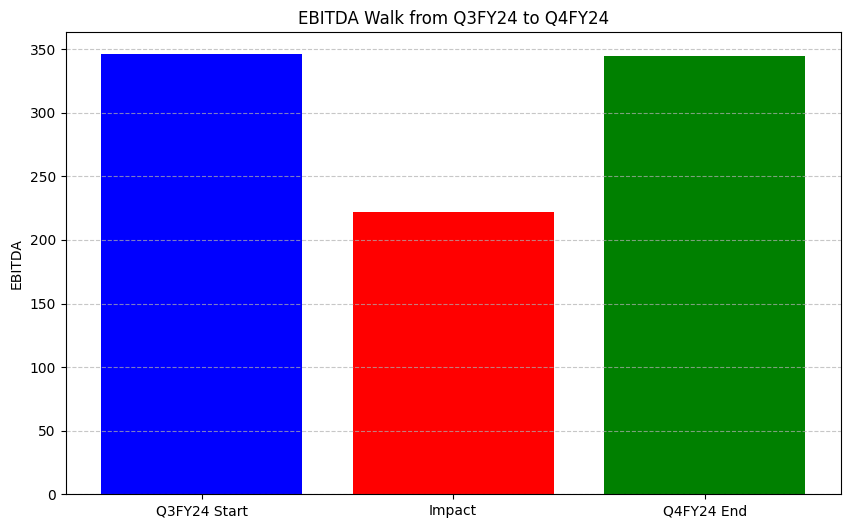

In [40]:
run_ebitda_walk_analysis_plot(final_df, query, llm)

In [8]:
import matplotlib.pyplot as plt
import io
import base64

def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png")
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")


In [9]:

def plot_ebitda_walk(df):
    # Assuming your df has a row like "EW_QxFY24_QyFY24"
    walk_row = df[df.index.str.contains("EW_")].iloc[0]

    labels = [
        "EBITDA_From_Quarter", "Sales", "LME", "Strategic Hedging", "Premium", "Realization",
        "Total Cost", "Alumina", "Power", "Other Hot Metal", "Conversion & Other", "EBITDA_To_Quarter"
    ]
    values = [walk_row[label] for label in labels]

    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Waterfall base calculation
    cum_values = [values[0]]
    for v in values[1:-1]:
        cum_values.append(cum_values[-1] + v)
    cum_values.append(values[-1])  # Ending EBITDA fixed

    # Bar colors
    colors = ['darkblue'] + ['green' if v >= 0 else 'red' for v in values[1:-1]] + ['darkblue']

    # Plot bars
    for i in range(len(values)):
        if i == 0 or i == len(values) - 1:
            ax.bar(i, values[i], color=colors[i])
        else:
            ax.bar(i, values[i], bottom=cum_values[i-1], color=colors[i])

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_title("EBITDA Walk (Mn$)")
    ax.set_ylabel("EBITDA Impact")
    
    # Add value labels above bars
    for i, (label, value) in enumerate(zip(labels, values)):
        ax.text(i, cum_values[i] + (value/2 if value >= 0 else -value/2), f"{value:.1f}", ha='center', va='bottom', fontsize=8)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    return fig


In [ ]:

def run_ebitda_walk_analysis_plot(final_df, query, llm):
    # ⛔️ No PandasAI for plotting now! Only use it for logic/text if needed.

    # Assume direct plotting
    fig = plot_ebitda_walk(final_df)
    return {"type": "image", "data": fig_to_base64(fig)}
